# DataLens Exploration

This notebook walks through the `datalens` package end to end on the bundled
sample dataset (`data/sample.csv`): a synthetic coffee shop's sales log with
columns `date`, `store`, `category`, `item`, `quantity`, `unit_price`, and
`revenue`.

The dataset is deliberately a little messy - it has a handful of duplicate
rows and missing values baked in (see `scripts/generate_sample_data.py`) -
so the cleaning functions below have real work to do, the same as they
would on a real export.

We'll:
1. Load and preview the raw data
2. Clean it with `datalens.cleaning`
3. Summarise it with `datalens.analysis`
4. Chart revenue by category and over time


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Make the sibling `datalens` package importable when running this notebook
# straight out of the repo (no install required).
sys.path.insert(0, str(Path.cwd().parent))

from datalens.analysis import group_by_summary, rolling_average, summarize
from datalens.cleaning import clean_data

%matplotlib inline


## 1. Load and preview the raw data

In [ ]:
root = Path.cwd()
file = "sample.csv"
while not (root / "data" / file).exists() and root != root.parent:
    root = root.parent

filepath = root / "data" / file
if not filepath.exists():
    raise FileNotFoundError(f"Could not find {file}")

raw = pd.read_csv(filepath)
print(f"{len(raw)} rows, {len(raw.columns)} columns")
raw.head()

816 rows, 7 columns


,date,store,category,item,quantity,unit_price,revenue
0,2026-05-17,Downtown,merch,Mug,2.0,11.98,23.96
1,2026-02-09,Riverside,tea,Green Tea,3.0,3.07,9.21
2,2026-02-17,Riverside,sandwich,BLT,3.0,7.04,21.12
3,2026-06-10,Downtown,coffee,Drip Coffee,2.0,2.85,5.70
4,2026-03-21,Riverside,tea,Green Tea,7.0,2.86,20.02


## 2. Clean the data

`clean_data` runs the standard pipeline: coerce column types (dates and
numerics), drop exact-duplicate rows, then handle missing values (default
strategy is to drop rows with any missing field - see
`datalens.cleaning.handle_missing_values` for a `"fill"` strategy that
imputes instead).

In [3]:
cleaned = clean_data(raw)
print(f"raw: {len(raw)} rows -> cleaned: {len(cleaned)} rows "
      f"({len(raw) - len(cleaned)} rows removed as duplicates or incomplete)")
cleaned.head()


raw: 816 rows -> cleaned: 779 rows (37 rows removed as duplicates or incomplete)


,date,store,category,item,quantity,unit_price,revenue
0,2026-05-17,Downtown,merch,Mug,2.0,11.98,23.96
1,2026-02-09,Riverside,tea,Green Tea,3.0,3.07,9.21
2,2026-02-17,Riverside,sandwich,BLT,3.0,7.04,21.12
3,2026-06-10,Downtown,coffee,Drip Coffee,2.0,2.85,5.70
4,2026-03-21,Riverside,tea,Green Tea,7.0,2.86,20.02


## 3. Summary statistics

In [4]:
summary = summarize(cleaned)
for key, value in summary.items():
    print(f"{key}: {value}")


row_count: 779
columns: ['date', 'store', 'category', 'item', 'quantity', 'unit_price', 'revenue']
total_revenue: 18853.21
mean_revenue: 24.20181001283697
total_quantity: 2678.0
category_count: 5
date_min: 2026-01-01
date_max: 2026-06-30


## 4. Revenue by category

In [5]:
by_category = group_by_summary(cleaned, by="category", value_column="revenue")
by_category


,total_revenue,mean_revenue,count
category,,,
merch,10022.75,64.248397,156
sandwich,3472.07,24.451197,142
coffee,1968.42,11.929818,165
pastry,1753.05,10.251754,171
tea,1636.92,11.289103,145


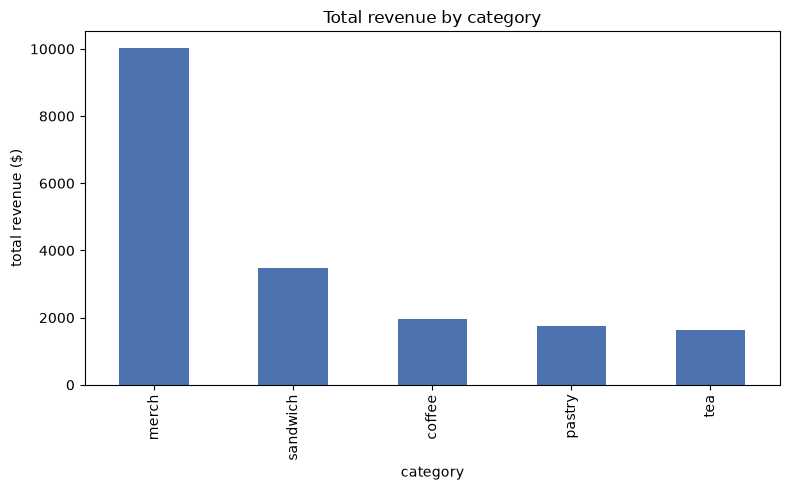

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
by_category["total_revenue"].plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Total revenue by category")
ax.set_xlabel("category")
ax.set_ylabel("total revenue ($)")
fig.tight_layout()
plt.show()


## 5. Revenue trend over time

`rolling_average` groups revenue by day and applies a rolling mean, which
smooths out day-to-day noise so the underlying trend is easier to read.

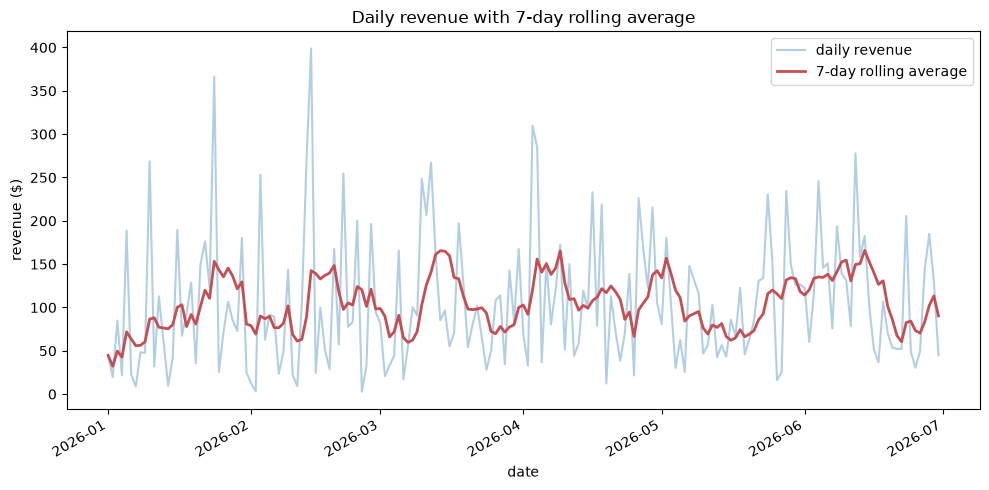

In [7]:
trend = rolling_average(cleaned, column="revenue", window=7, date_column="date")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(trend.index, trend["revenue"], alpha=0.35, label="daily revenue")
ax.plot(trend.index, trend["revenue_rolling_avg"], color="#C44E52", linewidth=2,
        label="7-day rolling average")
ax.set_title("Daily revenue with 7-day rolling average")
ax.set_xlabel("date")
ax.set_ylabel("revenue ($)")
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


## Next steps

This only scratches the surface of what's in `datalens`. Some ideas worth
exploring, several of which are open as issues in this repo:

- Outlier detection on `revenue` or `quantity` per category
- A `datalens report` CLI command that writes this kind of summary to a
  markdown file automatically
- A second sample dataset (different schema) to test reconciliation logic
  against
- More chart types - a line chart over time is a natural first PR

See `CONTRIBUTING.md` for how to claim an issue and get a PR up quickly.